In [10]:
from google.colab import drive

In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")
/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")



--- VALORES NULOS ---
+---+------+---------+----+
|Ano|Obitos|Populacao|Taxa|
+---+------+---------+----+
|  0|     0|        0|   0|
+---+------+---------+----+

--- ESTATÍSTICAS (MÉDIA, DESVIO PADRÃO, ETC) ---
+-----------------+------------------+------------------+------------------+
|     Media_Obitos|     Desvio_Obitos|         Media_Pop|   Media_Taxa_100k|
+-----------------+------------------+------------------+------------------+
|841.6521739130435|158.16378412486105|6303419.0869565215|13.438063828440686|
+-----------------+------------------+------------------+------------------+

+-------+-----------------+------------------+------------------+------------------+
|summary|              Ano|            Obitos|         Populacao|              Taxa|
+-------+-----------------+------------------+------------------+------------------+
|  count|               23|                23|                23|                23|
|   mean|           2011.0| 841.6521739130435|6303419.0869565

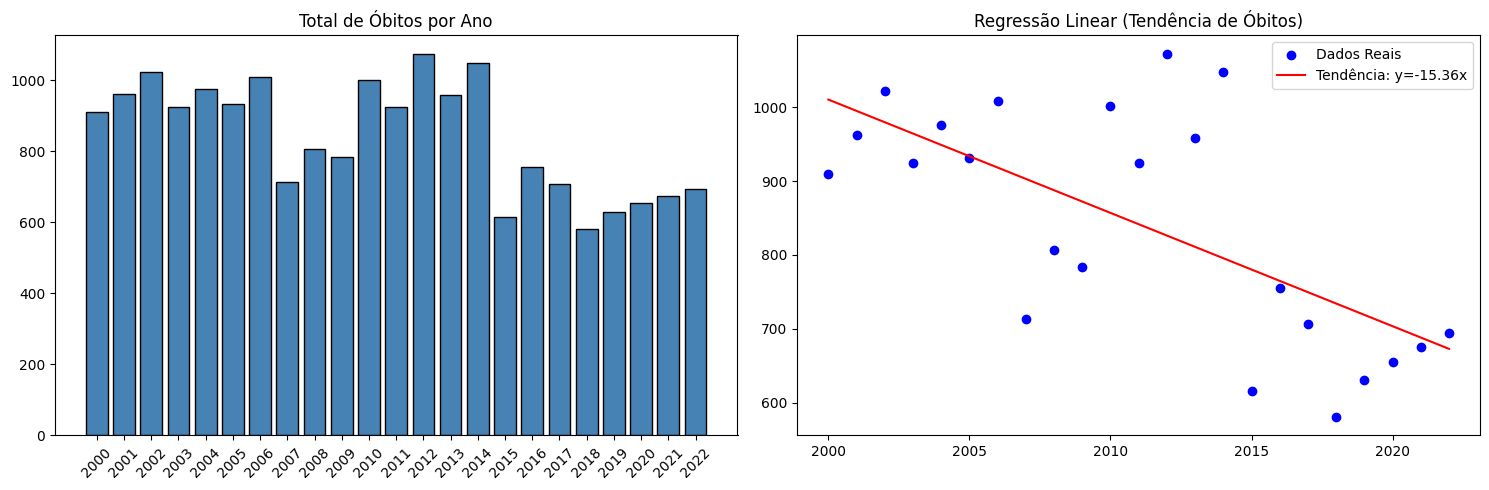

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import unicodedata
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, mean, stddev

# Funçao auxiliar para remover acentos e padronizar nomes
def normalizar_texto(texto):
    if not isinstance(texto, str): return str(texto)
    texto = texto.lower().strip()
    return "".join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

def iniciar_projeto():
    return SparkSession.builder.appName("AnaliseMortalidade").getOrCreate()

def processar_dados(caminho):
    # 1. Carrega o Excel
    pdf_bruto = pd.read_excel(caminho)

    # 2. Localiza a linha do cabeçalho
    linha_cabecalho = 0
    for i, linha in pdf_bruto.iterrows():
        valores = [normalizar_texto(v) for v in linha.values]
        if 'ano' in valores:
            linha_cabecalho = i
            break

    # Re-le o arquivo a partir da linha correta
    pdf = pd.read_excel(caminho, skiprows=linha_cabecalho + 1)
    # Se o skiprows falhar em pegar os nomes, usamos a linha detectada:
    if 'Ano' not in pdf.columns:
        pdf.columns = pdf_bruto.iloc[linha_cabecalho].values

    # 3. Mapeamento Inteligente de Colunas
    cols_originais = pdf.columns
    mapeamento = {}

    for c in cols_originais:
        norm = normalizar_texto(c)
        if 'ano' in norm: mapeamento['ano'] = c
        elif 'obito' in norm: mapeamento['obitos'] = c
        elif 'popula' in norm: mapeamento['populacao'] = c
        elif 'taxa' in norm: mapeamento['taxa'] = c

    # Verifica se encontrou as colunas essenciais
    if 'ano' not in mapeamento or 'obitos' not in mapeamento:
        print("Colunas encontradas:", list(cols_originais))
        raise ValueError("Não foi possível encontrar as colunas de 'Ano' ou 'Óbitos'. Verifique os nomes na planilha.")

    # 4. Limpeza e Conversão
    for chave, nome_real in mapeamento.items():
        pdf[nome_real] = pd.to_numeric(pdf[nome_real], errors='coerce')

    # Remove nulos e ordena por ano
    pdf = pdf.dropna(subset=[mapeamento['ano'], mapeamento['obitos']])
    pdf = pdf.sort_values(by=mapeamento['ano'])

    # Renomeia para nomes simples (evita erro no Spark com caracteres especiais)
    pdf = pdf.rename(columns={
        mapeamento['ano']: 'Ano',
        mapeamento['obitos']: 'Obitos',
        mapeamento['populacao']: 'Populacao',
        mapeamento['taxa']: 'Taxa'
    })

    return pdf[['Ano', 'Obitos', 'Populacao', 'Taxa']]

def realizar_analise_estatistica(spark, pdf):
    df_spark = spark.createDataFrame(pdf)

    print("\n--- VALORES NULOS ---")
    df_spark.select([count(when(col(c).isNull(), c)).alias(c) for c in df_spark.columns]).show()

    print("--- ESTATÍSTICAS (MÉDIA, DESVIO PADRÃO, ETC) ---")
    # Calcula estatísticas para as colunas solicitadas
    df_spark.select(
        mean("Obitos").alias("Media_Obitos"),
        stddev("Obitos").alias("Desvio_Obitos"),
        mean("Populacao").alias("Media_Pop"),
        mean("Taxa").alias("Media_Taxa_100k")
    ).show()

    df_spark.describe().show()
    return df_spark

def gerar_graficos(pdf):
    x = pdf['Ano'].values
    y = pdf['Obitos'].values

    # Regressão Linear
    m, b = np.polyfit(x, y, 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfico 1: Barras
    ax1.bar(x.astype(int).astype(str), y, color='steelblue', edgecolor='black')
    ax1.set_title('Total de Óbitos por Ano')
    ax1.tick_params(axis='x', rotation=45)

    # Gráfico 2: Regressão
    ax2.scatter(x, y, color='blue', label='Dados Reais')
    ax2.plot(x, m*x + b, color='red', label=f'Tendência: y={m:.2f}x')
    ax2.set_title('Regressão Linear (Tendência de Óbitos)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# EXECUÇÃO PRINCIPAL
try:
    sessao = iniciar_projeto()
    caminho = "/content/drive/MyDrive/Trabalho/dados_transito.xlsx"

    if os.path.exists(caminho):
        df_limpo = processar_dados(caminho)
        realizar_analise_estatistica(sessao, df_limpo)
        gerar_graficos(df_limpo)
    else:
        print("Arquivo não encontrado no Drive.")
finally:
    if 'sessao' in locals(): sessao.stop()